# Causal Discovery Under a Simulator: Lessons from the ADIA Lab Challenge

**Chapter 15: Causal Estimation with ML**
**Docker image**: `ml4t`

This notebook explores the **ADIA Lab Causal Discovery Challenge** (Olivetti et al., 2026)
as a **cautionary, clarifying example** of what synthetic benchmarks can and cannot
demonstrate about causal discovery.

**The Key Insight**: ADIA is best interpreted as a benchmark for **amortized inference
under a known simulator family**, not as evidence that "AI can discover causal structure"
in the usual scientific sense. Supervised models won because they learned the simulator's
mapping from dependence patterns to labels—not because they discovered causality.

**What ADIA Shows**:
- If you have many labeled dataset–DAG pairs from the same data-generating process,
  supervised methods can outperform classical discovery on new samples from that family

**What ADIA Does NOT Show**:
- That observational data alone is sufficient for reliable causal discovery
- That these models transfer to real financial data with unmeasured confounding,
  nonstationarity, and endogenous sampling

**Learning Outcomes**:
- LO1: Understand the "special setting" where supervised causal discovery applies
- LO2: Recognize why synthetic benchmarks can be misleading ("varsortability" critique)
- LO3: Apply discovery outputs as hypothesis generators, not final answers
- LO4: Integrate causal proposals into a finance-appropriate validation pipeline

**Book Reference**: Chapter 15, Section 15.5 (Time Series Causal Discovery)

**Prerequisites**: [`07_tigramite_time_series`](07_tigramite_time_series.ipynb) and
[`08_neural_causal_discovery`](08_neural_causal_discovery.ipynb) for discovery methods

## 1. Setup and Configuration

In [1]:
"""Causal Discovery Under a Simulator — lessons from the ADIA Lab Challenge on synthetic benchmarks."""

import warnings

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy import stats
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler

import utils  # noqa: F401
from utils.reproducibility import set_global_seeds

warnings.filterwarnings("ignore")

In [2]:
N_DATASETS = 2000
N_SAMPLES = 1000
N_SPLITS = 5
SEED = 42
N_ESTIMATORS = 500

In [3]:
set_global_seeds(SEED)

print("ADIA Causal Discovery Benchmark")

ADIA Causal Discovery Benchmark


## 2. What ADIA Actually Measures (and What It Doesn't)

### The Special Setting

The ADIA competition operates in a **"special setting"** that differs fundamentally
from real-world causal discovery:

1. **Many labeled dataset–DAG pairs** from the same data-generating process
2. **Task is role classification** (8 categories around X,Y), not full DAG recovery
3. **Synthetic data** with no unmeasured confounding, measurement error, or nonstationarity

This design turns "causal discovery" into **high-dimensional pattern recognition**:
learn a mapping from sample-level dependence patterns to role labels, where the
mapping is stable because the simulator is stable.

### Why Supervised Learning Wins Here

Supervised models dominate because:

1. **Training labels remove the identifiability bottleneck**: The learner doesn't
   need to solve identifiability—it learns any stable statistical signature
2. **The task is narrower**: Role classification in a 1-hop neighborhood is easier
   than reconstructing an entire DAG up to Markov equivalence
3. **Hybrid entries used classical outputs as features**: PC/NOTEARS outputs become
   inputs to boosted trees—classical discovery as feature engineering

### The "Varsortability" Critique

Reisach et al. (2021) warn that synthetic DAG benchmarks can be "gamed" because
common simulation schemes create artifacts correlated with causal order. A model
can win by learning **simulator quirks rather than transferable causal principles**.

### What This Does NOT Show

ADIA does **not** support the claim that observational data in the wild is sufficient
for reliable causal discovery. The hard parts are deliberately excluded:

- Unmeasured confounding (absent in synthetic data)
- Measurement error, nonstationarity, regime changes
- Feedback loops and simultaneity
- Selection effects and endogenous sampling
- Time-order constraints and mixed frequencies

---

## 3. The 8 Causal Categories

The ADIA challenge defines **8 causal categories** for each variable in a DAG
relative to a designated treatment (X) and outcome (Y):

| Category | Description | DAG Position |
|----------|-------------|--------------|
| **Confounder** | Common cause of X and Y | X ← Z → Y |
| **Collider** | Common effect of X and Y | X → Z ← Y |
| **Mediator** | On causal path | X → Z → Y |
| **Independent** | No relationship | Z ⊥ (X,Y) |
| **Cause of X** | Direct parent of X | Z → X |
| **Consequence of X** | Direct child of X (not Y) | X → Z (Z ≠ Y) |
| **Cause of Y** | Direct parent of Y (not X) | Z → Y (Z ≠ X) |
| **Consequence of Y** | Direct child of Y | Y → Z |

**Why This Is Hard**: Given only observational data, distinguishing these categories
requires inferring the underlying causal structure—exactly what traditional
algorithms like PC and NOTEARS struggle with.

In [4]:
# Define the 8 causal categories
CAUSAL_CATEGORIES = {
    0: "Confounder",  # Common cause of X and Y
    1: "Collider",  # Common effect of X and Y
    2: "Mediator",  # On causal path X → M → Y
    3: "Independent",  # No causal relationship
    4: "Cause_of_X",  # Direct cause of treatment
    5: "Consequence_of_X",  # Direct effect of treatment (not Y)
    6: "Cause_of_Y",  # Direct cause of outcome (not X)
    7: "Consequence_of_Y",  # Direct effect of outcome
}

print("Causal Categories for Classification:")
for idx, name in CAUSAL_CATEGORIES.items():
    print(f"  {idx}: {name}")

Causal Categories for Classification:
  0: Confounder
  1: Collider
  2: Mediator
  3: Independent
  4: Cause_of_X
  5: Consequence_of_X
  6: Cause_of_Y
  7: Consequence_of_Y


## 3. Generate Synthetic Training Data with Known DAGs

The ADIA challenge provided 25,000 training datasets with ground-truth DAGs.
We generate our own synthetic data to demonstrate the methodology.

**Data Generation Protocol**:
1. Generate random DAGs with 5-8 variables
2. Designate treatment (X) and outcome (Y) variables
3. Classify each other variable into one of 8 categories
4. Generate observational data from the DAG
5. Create labeled training examples

### Generate Random DAGs

Generate random DAG adjacency matrices using topological ordering to
ensure acyclicity: edges can only go from lower-indexed to higher-indexed nodes.

In [5]:
def generate_random_dag(n_vars: int, edge_prob: float = 0.3) -> np.ndarray:
    """Generate a random DAG adjacency matrix (lower → higher index only)."""
    W = np.zeros((n_vars, n_vars))
    for i in range(n_vars):
        for j in range(i + 1, n_vars):
            if np.random.random() < edge_prob:
                W[i, j] = 1
    return W

### Classify Variable Roles

Given a DAG, classify each variable Z relative to treatment X and outcome Y
into one of the 8 causal categories defined above.

In [6]:
def classify_variable(W: np.ndarray, x_idx: int, y_idx: int, z_idx: int) -> int:
    """Classify variable Z relative to treatment X and outcome Y. Returns category 0-7."""
    z_causes_x = W[z_idx, x_idx] == 1
    x_causes_z = W[x_idx, z_idx] == 1
    z_causes_y = W[z_idx, y_idx] == 1
    y_causes_z = W[y_idx, z_idx] == 1

    is_mediator = x_causes_z and z_causes_y
    is_confounder = z_causes_x and z_causes_y
    is_collider = x_causes_z and y_causes_z

    if is_confounder:
        return 0
    elif is_collider:
        return 1
    elif is_mediator:
        return 2
    elif z_causes_x and not z_causes_y:
        return 4  # Cause of X only
    elif x_causes_z and not z_causes_y and not y_causes_z:
        return 5  # Consequence of X
    elif z_causes_y and not z_causes_x:
        return 6  # Cause of Y only
    elif y_causes_z:
        return 7  # Consequence of Y
    else:
        return 3  # Independent

### Generate Data from DAG

Generate observational data from a linear Gaussian DAG in topological order.

In [7]:
def generate_data_from_dag(
    W: np.ndarray, n_samples: int = 1000, noise_scale: float = 1.0
) -> np.ndarray:
    """Generate observational data from a linear Gaussian DAG."""
    n_vars = W.shape[0]
    W_weighted = W * np.random.uniform(0.5, 1.5, size=W.shape)

    X = np.zeros((n_samples, n_vars))
    for j in range(n_vars):
        parents = np.where(W_weighted[:, j] > 0)[0]
        noise = np.random.randn(n_samples) * noise_scale
        if len(parents) == 0:
            X[:, j] = noise
        else:
            X[:, j] = X[:, parents] @ W_weighted[parents, j] + noise

    return X

### Synthetic Training Dataset Generator

Build randomized DAG datasets with labeled variable roles for supervised
classification of causal structure categories.

In [8]:
def generate_training_dataset(
    n_datasets: int = 1000,
    min_vars: int = 5,
    max_vars: int = 8,
    n_samples: int = 1000,
) -> tuple[list, list, list]:
    """
    Generate synthetic training data with known causal categories.

    Returns:
        datasets: List of data matrices
        labels: List of label arrays (one per variable, excluding X and Y)
        metadata: List of (W, x_idx, y_idx) tuples
    """
    datasets = []
    labels = []
    metadata = []

    for dataset_id in range(n_datasets):
        # Random number of variables
        n_vars = np.random.randint(min_vars, max_vars + 1)

        # Generate DAG
        W = generate_random_dag(n_vars, edge_prob=0.35)

        # Ensure at least one path exists by potentially adding edges
        # Pick X and Y such that X has lower index (can cause Y)
        x_idx = np.random.randint(0, n_vars - 1)
        y_idx = np.random.randint(x_idx + 1, n_vars)

        # Generate data
        X = generate_data_from_dag(W, n_samples)

        # Classify each variable (except X and Y)
        dataset_labels = []
        for z_idx in range(n_vars):
            if z_idx in (x_idx, y_idx):
                continue
            category = classify_variable(W, x_idx, y_idx, z_idx)
            dataset_labels.append((z_idx, category))

        datasets.append(X)
        labels.append(dataset_labels)
        metadata.append((W, x_idx, y_idx))

    return datasets, labels, metadata

In [9]:
print("\n=== GENERATING SYNTHETIC TRAINING DATA ===\n")

datasets, labels, metadata = generate_training_dataset(
    n_datasets=N_DATASETS,
    min_vars=5,
    max_vars=8,
    n_samples=N_SAMPLES,
)

# Count category distribution
all_labels = []
for label_list in labels:
    for _, cat in label_list:
        all_labels.append(cat)

label_counts = pd.Series(all_labels).value_counts().sort_index()
print("Category Distribution in Training Data:")
for cat_idx, count in label_counts.items():
    print(f"  {CAUSAL_CATEGORIES[cat_idx]}: {count} ({count / len(all_labels):.1%})")

print(f"\nTotal datasets: {len(datasets)}")
print(f"Total labeled examples: {len(all_labels)}")


=== GENERATING SYNTHETIC TRAINING DATA ===



Category Distribution in Training Data:
  Confounder: 562 (6.3%)
  Collider: 268 (3.0%)
  Mediator: 297 (3.3%)
  Independent: 3762 (42.1%)
  Cause_of_X: 980 (11.0%)
  Consequence_of_X: 1024 (11.5%)
  Cause_of_Y: 1499 (16.8%)
  Consequence_of_Y: 536 (6.0%)

Total datasets: 2000
Total labeled examples: 8928


## 4. Feature Engineering: The Winning Approach

The 4th place solution (72.88% accuracy) used **923 engineered features** from:

1. **Correlation Statistics**: Pearson, Spearman, partial correlations
2. **Conditional Independence**: CI test p-values, conditional correlations
3. **Causal Discovery Outputs**: Use traditional algorithm outputs as features
4. **Graph Properties**: In-degree, out-degree estimates

**Key Insight**: Traditional algorithms (PC, NOTEARS) achieve ~40% on their own,
but their *outputs* become valuable *features* for a supervised classifier.

In [10]:
def compute_partial_correlation(data: np.ndarray, i: int, j: int, conditioning_set: list) -> float:
    """Compute partial correlation between variables i and j given conditioning set."""
    if len(conditioning_set) == 0:
        return np.corrcoef(data[:, i], data[:, j])[0, 1]

    from sklearn.linear_model import LinearRegression

    X_cond = data[:, conditioning_set]
    resid_i = data[:, i] - LinearRegression().fit(X_cond, data[:, i]).predict(X_cond)
    resid_j = data[:, j] - LinearRegression().fit(X_cond, data[:, j]).predict(X_cond)
    return np.corrcoef(resid_i, resid_j)[0, 1]

### Conditional Independence Test Feature

Fisher-z transformed partial-correlation test used as a core engineered
feature for the ADIA benchmark classifier.

In [11]:
def ci_test_pvalue(data: np.ndarray, i: int, j: int, conditioning_set: list) -> float:
    """CI test using partial correlation + Fisher's z. Returns p-value for H0: i _|_ j | S."""
    n, k = len(data), len(conditioning_set)
    partial_corr = compute_partial_correlation(data, i, j, conditioning_set)

    if np.isnan(partial_corr) or abs(partial_corr) >= 1:
        return 1.0

    z = 0.5 * np.log((1 + partial_corr) / (1 - partial_corr))
    z_stat = abs(z) / (1.0 / np.sqrt(n - k - 3))
    return 2 * (1 - stats.norm.cdf(z_stat))

### Core Feature Extraction

Extract correlation, partial correlation, CI p-values, and regression features.

In [12]:
def _extract_correlation_features(data, x_idx, y_idx, z_idx):
    """Correlations, partial correlations, and CI test p-values."""
    f = {}
    f["corr_z_x"] = np.corrcoef(data[:, z_idx], data[:, x_idx])[0, 1]
    f["corr_z_y"] = np.corrcoef(data[:, z_idx], data[:, y_idx])[0, 1]
    f["corr_x_y"] = np.corrcoef(data[:, x_idx], data[:, y_idx])[0, 1]
    f["abs_corr_z_x"] = abs(f["corr_z_x"])
    f["abs_corr_z_y"] = abs(f["corr_z_y"])

    f["partial_z_x_given_y"] = compute_partial_correlation(data, z_idx, x_idx, [y_idx])
    f["partial_z_y_given_x"] = compute_partial_correlation(data, z_idx, y_idx, [x_idx])
    f["partial_x_y_given_z"] = compute_partial_correlation(data, x_idx, y_idx, [z_idx])

    f["ci_pvalue_z_x"] = ci_test_pvalue(data, z_idx, x_idx, [])
    f["ci_pvalue_z_y"] = ci_test_pvalue(data, z_idx, y_idx, [])
    f["ci_pvalue_z_x_given_y"] = ci_test_pvalue(data, z_idx, x_idx, [y_idx])
    f["ci_pvalue_z_y_given_x"] = ci_test_pvalue(data, z_idx, y_idx, [x_idx])
    f["ci_pvalue_x_y_given_z"] = ci_test_pvalue(data, x_idx, y_idx, [z_idx])
    return f

### Regression and Statistical Features

Regression coefficients for directionality, plus higher-order statistics and
topological hints from variable ordering.

In [13]:
def extract_features(data: np.ndarray, x_idx: int, y_idx: int, z_idx: int) -> dict:
    """Extract all features for classifying variable Z relative to X and Y."""
    from sklearn.linear_model import LinearRegression

    n_vars = data.shape[1]
    features = _extract_correlation_features(data, x_idx, y_idx, z_idx)

    # Regression coefficients (direction indicators)
    for src, tgt, prefix in [
        (z_idx, x_idx, "z_to_x"),
        (x_idx, z_idx, "x_to_z"),
        (z_idx, y_idx, "z_to_y"),
        (y_idx, z_idx, "y_to_z"),
    ]:
        m = LinearRegression().fit(data[:, [src]], data[:, tgt])
        features[f"reg_coef_{prefix}"] = m.coef_[0]
        features[f"reg_r2_{prefix}"] = m.score(data[:, [src]], data[:, tgt])

    # Higher-order statistics
    features["skew_z"] = stats.skew(data[:, z_idx])
    features["kurtosis_z"] = stats.kurtosis(data[:, z_idx])
    features["skew_x"] = stats.skew(data[:, x_idx])
    features["skew_y"] = stats.skew(data[:, y_idx])

    # Variance ratios
    features["var_z"] = np.var(data[:, z_idx])
    features["var_ratio_z_x"] = np.var(data[:, z_idx]) / (np.var(data[:, x_idx]) + 1e-10)
    features["var_ratio_z_y"] = np.var(data[:, z_idx]) / (np.var(data[:, y_idx]) + 1e-10)

    # Spearman (rank-based)
    features["spearman_z_x"] = stats.spearmanr(data[:, z_idx], data[:, x_idx])[0]
    features["spearman_z_y"] = stats.spearmanr(data[:, z_idx], data[:, y_idx])[0]

    # Position-based (topological hints)
    features["z_idx_normalized"] = z_idx / n_vars
    features["x_idx_normalized"] = x_idx / n_vars
    features["y_idx_normalized"] = y_idx / n_vars
    features["z_before_x"] = float(z_idx < x_idx)
    features["z_between_x_y"] = float(x_idx < z_idx < y_idx)
    features["z_after_y"] = float(z_idx > y_idx)

    for key, value in features.items():
        if np.isnan(value):
            features[key] = 0.0
    return features

In [14]:
print("\n=== EXTRACTING FEATURES ===\n")

# Build feature matrix and labels
all_features = []
all_targets = []
all_dataset_ids = []  # For grouped CV

for dataset_id, (data, label_list, (W, x_idx, y_idx)) in enumerate(
    zip(datasets, labels, metadata, strict=False)
):
    for z_idx, category in label_list:
        features = extract_features(data, x_idx, y_idx, z_idx)
        all_features.append(features)
        all_targets.append(category)
        all_dataset_ids.append(dataset_id)

    # Progress indicator
    if (dataset_id + 1) % 500 == 0:
        print(f"  Processed {dataset_id + 1}/{len(datasets)} datasets")

# Convert to arrays
feature_df = pd.DataFrame(all_features)
X_train = feature_df.values
y_train = np.array(all_targets)
groups = np.array(all_dataset_ids)

print(f"\nFeature matrix shape: {X_train.shape}")
print(f"Number of features: {feature_df.shape[1]}")
print(f"Feature names: {list(feature_df.columns)[:10]}...")


=== EXTRACTING FEATURES ===



  Processed 500/2000 datasets


  Processed 1000/2000 datasets


  Processed 1500/2000 datasets


  Processed 2000/2000 datasets

Feature matrix shape: (8928, 36)
Number of features: 36
Feature names: ['corr_z_x', 'corr_z_y', 'corr_x_y', 'abs_corr_z_x', 'abs_corr_z_y', 'partial_z_x_given_y', 'partial_z_y_given_x', 'partial_x_y_given_z', 'ci_pvalue_z_x', 'ci_pvalue_z_y']...


## 5. Baseline: PC Algorithm Performance

Traditional causal discovery algorithms like PC achieved ~37-40% balanced accuracy
on the ADIA benchmark. We implement a simplified baseline to demonstrate this.

In [15]:
def pc_algorithm_baseline(data: np.ndarray, x_idx: int, y_idx: int, z_idx: int) -> int:
    """Simplified PC-algorithm classification using CI test heuristics."""
    alpha = 0.05
    p_zx = ci_test_pvalue(data, z_idx, x_idx, [])
    p_zy = ci_test_pvalue(data, z_idx, y_idx, [])
    p_zx_given_y = ci_test_pvalue(data, z_idx, x_idx, [y_idx])
    p_zy_given_x = ci_test_pvalue(data, z_idx, y_idx, [x_idx])
    p_xy_given_z = ci_test_pvalue(data, x_idx, y_idx, [z_idx])

    if p_zx > alpha and p_zy > alpha:
        return 3  # Independent
    if p_zx < alpha and p_zy < alpha:
        if p_xy_given_z > p_zx * p_zy:
            return 0  # Confounder
        if p_zx_given_y > alpha and p_zy_given_x > alpha:
            return 2  # Mediator
    if p_zx < alpha and p_zy_given_x > alpha:
        return 4  # Cause of X
    if p_zy < alpha and p_zx_given_y > alpha:
        return 6  # Cause of Y
    if p_zx < alpha:
        return 5  # Consequence of X
    if p_zy < alpha:
        return 7  # Consequence of Y
    return 3  # Default: Independent

In [16]:
print("\n=== PC ALGORITHM BASELINE ===\n")

# Evaluate PC baseline on a subset
N_EVAL = min(500, len(datasets))
pc_predictions = []
pc_true_labels = []

for dataset_id in range(N_EVAL):
    data = datasets[dataset_id]
    W, x_idx, y_idx = metadata[dataset_id]

    for z_idx, true_category in labels[dataset_id]:
        pred = pc_algorithm_baseline(data, x_idx, y_idx, z_idx)
        pc_predictions.append(pred)
        pc_true_labels.append(true_category)

pc_accuracy = balanced_accuracy_score(pc_true_labels, pc_predictions)
print(f"PC Algorithm Balanced Accuracy: {pc_accuracy:.1%}")
print("(ADIA benchmark PC baseline: 37.79%)")

# Per-class accuracy
print("\nPer-Category Accuracy (PC Baseline):")
for cat_idx, cat_name in CAUSAL_CATEGORIES.items():
    mask = np.array(pc_true_labels) == cat_idx
    if mask.sum() > 0:
        acc = (np.array(pc_predictions)[mask] == cat_idx).mean()
        print(f"  {cat_name}: {acc:.1%}")


=== PC ALGORITHM BASELINE ===



PC Algorithm Balanced Accuracy: 23.4%
(ADIA benchmark PC baseline: 37.79%)

Per-Category Accuracy (PC Baseline):
  Confounder: 35.3%
  Collider: 0.0%
  Mediator: 0.0%
  Independent: 45.9%
  Cause_of_X: 48.1%
  Consequence_of_X: 22.1%
  Cause_of_Y: 34.5%
  Consequence_of_Y: 1.6%


## 6. Supervised Learning: LightGBM Classifier

The winning solutions used supervised classifiers trained on the 25,000 datasets
with known ground truth. We use LightGBM following the 4th place solution approach.

In [17]:
import lightgbm as lgb

In [18]:
print("\n=== TRAINING SUPERVISED CLASSIFIER ===\n")

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# StratifiedGroupKFold: examples from same dataset stay in same fold
cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

n_estimators = N_ESTIMATORS


=== TRAINING SUPERVISED CLASSIFIER ===



In [19]:
# Training loop with out-of-fold predictions
all_oof_preds = np.zeros(len(y_train), dtype=int)
all_oof_probs = np.zeros((len(y_train), 8))
fold_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_scaled, y_train, groups)):
    X_tr, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    model = lgb.LGBMClassifier(
        n_estimators=n_estimators,
        learning_rate=0.1,
        max_depth=6,
        num_leaves=31,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED,
        verbose=-1,
        class_weight="balanced",
    )

    model.fit(X_tr, y_tr)
    all_oof_preds[val_idx] = model.predict(X_val)
    all_oof_probs[val_idx] = model.predict_proba(X_val)

    fold_acc = balanced_accuracy_score(y_val, model.predict(X_val))
    fold_scores.append(fold_acc)
    print(f"  Fold {fold + 1}: Balanced Accuracy = {fold_acc:.1%}")

  Fold 1: Balanced Accuracy = 78.0%


  Fold 2: Balanced Accuracy = 76.3%


  Fold 3: Balanced Accuracy = 78.3%


  Fold 4: Balanced Accuracy = 76.9%


  Fold 5: Balanced Accuracy = 77.2%


In [20]:
oof_accuracy = balanced_accuracy_score(y_train, all_oof_preds)
print(f"\nOverall OOF Balanced Accuracy: {oof_accuracy:.1%}")
print(f"Mean +/- Std across folds: {np.mean(fold_scores):.1%} +/- {np.std(fold_scores):.1%}")
print("\n(ADIA benchmark 4th place: 72.88%)")
print("(ADIA benchmark winner: 76.70%)")


Overall OOF Balanced Accuracy: 77.3%
Mean +/- Std across folds: 77.3% +/- 0.7%

(ADIA benchmark 4th place: 72.88%)
(ADIA benchmark winner: 76.70%)


## 7. Model Analysis and Feature Importance

In [21]:
print("\n=== PER-CATEGORY ACCURACY COMPARISON ===\n")

per_category_rows = []
pc_true_arr = np.array(pc_true_labels)
pc_pred_arr = np.array(pc_predictions)
for cat_idx, cat_name in CAUSAL_CATEGORIES.items():
    mask_pc = pc_true_arr == cat_idx
    pc_acc = (pc_pred_arr[mask_pc] == cat_idx).mean() if mask_pc.sum() > 0 else 0.0
    mask_sup = y_train == cat_idx
    sup_acc = (all_oof_preds[mask_sup] == cat_idx).mean() if mask_sup.sum() > 0 else 0.0
    per_category_rows.append(
        {
            "Category": cat_name,
            "PC Baseline": pc_acc,
            "Supervised": sup_acc,
            "Improvement": sup_acc - pc_acc,
        }
    )

per_category_df = pd.DataFrame(per_category_rows).set_index("Category")
per_category_df.style.format("{:.1%}")


=== PER-CATEGORY ACCURACY COMPARISON ===



,PC Baseline,Supervised,Improvement
Category,,,
Confounder,35.3%,69.8%,34.5%
Collider,0.0%,68.3%,68.3%
Mediator,0.0%,78.5%,78.5%
Independent,45.9%,80.6%,34.8%
Cause_of_X,48.1%,80.5%,32.4%
Consequence_of_X,22.1%,80.3%,58.2%
Cause_of_Y,34.5%,82.2%,47.7%
Consequence_of_Y,1.6%,78.5%,76.9%


### Feature Importance

Train a final model on all data to extract feature importances.

In [22]:
final_model = lgb.LGBMClassifier(
    n_estimators=n_estimators,
    learning_rate=0.1,
    max_depth=6,
    random_state=SEED,
    verbose=-1,
    class_weight="balanced",
)

final_model.fit(X_scaled, y_train)

importance_df = pd.DataFrame(
    {"Feature": feature_df.columns, "Importance": final_model.feature_importances_}
).sort_values("Importance", ascending=False)

print("\nTop 15 Most Important Features:")
importance_df.head(15)


Top 15 Most Important Features:


,Feature,Importance
25,var_z,6880
6,partial_z_y_given_x,6334
22,kurtosis_z,5700
21,skew_z,5442
24,skew_y,5354
5,partial_z_x_given_y,5237
26,var_ratio_z_x,5217
15,reg_coef_x_to_z,5006
23,skew_x,4993
19,reg_coef_y_to_z,4875


## 8. Visualize Results

### Confusion Matrix

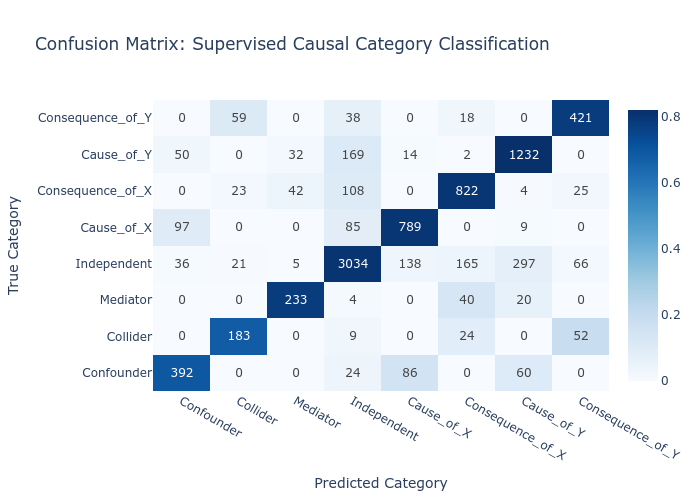

In [23]:
conf_matrix = confusion_matrix(y_train, all_oof_preds)
conf_matrix_normalized = conf_matrix / conf_matrix.sum(axis=1, keepdims=True)

cat_names = [CAUSAL_CATEGORIES[i] for i in range(8)]
fig = go.Figure(
    data=go.Heatmap(
        z=conf_matrix_normalized,
        x=cat_names,
        y=cat_names,
        colorscale="Blues",
        text=conf_matrix,
        texttemplate="%{text}",
        hovertemplate="True: %{y}<br>Predicted: %{x}<br>Count: %{text}<br>Rate: %{z:.1%}<extra></extra>",
    )
)
fig.update_layout(
    title="Confusion Matrix: Supervised Causal Category Classification",
    xaxis_title="Predicted Category",
    yaxis_title="True Category",
    height=500,
    width=700,
)
fig.show()

### Feature Importance

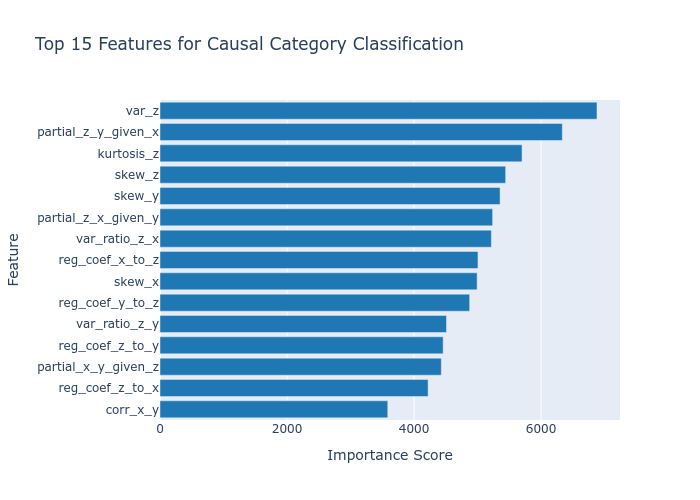

In [24]:
top_features = importance_df.head(15)
fig = go.Figure(
    data=go.Bar(
        x=top_features["Importance"],
        y=top_features["Feature"],
        orientation="h",
        marker_color="#1f77b4",
    )
)
fig.update_layout(
    title="Top 15 Features for Causal Category Classification",
    xaxis_title="Importance Score",
    yaxis_title="Feature",
    height=500,
    width=700,
    yaxis=dict(autorange="reversed"),
)
fig.show()

### Method Comparison

Contrast our supervised approach against the PC baseline and ADIA competition results.

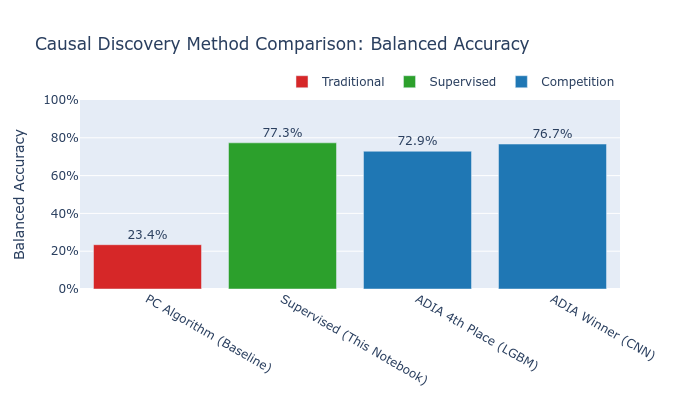

In [25]:
methods_comparison = pd.DataFrame(
    {
        "Method": [
            "PC Algorithm\n(Baseline)",
            "Supervised\n(This Notebook)",
            "ADIA 4th Place\n(LGBM)",
            "ADIA Winner\n(CNN)",
        ],
        "Balanced Accuracy": [pc_accuracy, oof_accuracy, 0.7288, 0.7670],
        "Type": ["Traditional", "Supervised", "Competition", "Competition"],
    }
)

colors = {"Traditional": "#d62728", "Supervised": "#2ca02c", "Competition": "#1f77b4"}
fig = go.Figure()
for method_type in methods_comparison["Type"].unique():
    mask = methods_comparison["Type"] == method_type
    fig.add_trace(
        go.Bar(
            x=methods_comparison[mask]["Method"],
            y=methods_comparison[mask]["Balanced Accuracy"],
            name=method_type,
            marker_color=colors[method_type],
            text=methods_comparison[mask]["Balanced Accuracy"].apply(lambda x: f"{x:.1%}"),
            textposition="outside",
        )
    )
fig.update_layout(
    title="Causal Discovery Method Comparison: Balanced Accuracy",
    yaxis_title="Balanced Accuracy",
    yaxis=dict(range=[0, 1], tickformat=".0%"),
    height=400,
    showlegend=True,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)
fig.show()

## 9. Key Takeaways: A Cautionary Example

### What ADIA Actually Demonstrates

The ADIA Lab challenge supports a **conditional claim**:

> **If** you can specify a data-generating family for which you can produce many
> labeled dataset–graph pairs, **then** supervised methods can outperform classical
> discovery on new samples from that same family.

It does **not** support the stronger claim that observational data in the wild
is sufficient for reliable causal discovery.

| Method Category | Balanced Accuracy | What It Shows |
|-----------------|-------------------|---------------|
| Traditional (PC, NOTEARS) | ~40% | Struggles even on clean synthetic data |
| Hybrid (classical as features) | ~74% | Classical outputs useful as inputs |
| Supervised (LGBM, CNN) | ~77% | Learns simulator's mapping, not causality |

### The "Amortized Inference" Framing

The winning approaches are best viewed as **meta-models over a simulator**, not
plug-and-play tools for unknown real causal graphs. They learn:

- Patterns specific to ADIA's synthetic DGP
- Mappings that may not transfer to real data
- Simulator quirks rather than universal causal principles

### Finance Translation: Proposal Generation, Not Truth

There *is* one practical insight worth incorporating:

**If you are willing to build a calibrated synthetic environment**, you can use it
to train amortized discovery models that produce **candidate proposals**—then
validate those proposals with domain constraints and out-of-sample checks.

Discovery outputs might propose:
- Plausible confounders to control for
- Likely colliders to avoid conditioning on
- Candidate mediators to separate mechanism from spurious association

But these proposals require your usual robustness pipeline:
- Walk-forward validation
- Regime splits
- Sensitivity analysis
- Placebo tests

### The Bottom Line

ADIA reinforces—rather than weakens—the book's skepticism about causal discovery.
Treat discovery methods as **tools for reducing false discovery**, not as automatic
truth machines. The winning solutions learned a simulator, not causality.

In [26]:
print("\n" + "=" * 70)
print("SUMMARY: ADIA AS A CAUTIONARY EXAMPLE")
print("=" * 70)

print(f"""
METHODOLOGY COMPARISON (on synthetic data):
  PC Algorithm (Traditional):     {pc_accuracy:.1%} balanced accuracy
  Supervised Learning (LGBM):     {oof_accuracy:.1%} balanced accuracy

ADIA COMPETITION RESULTS (Reference):
  PC Algorithm (baseline):        37.79%
  Supervised (CNN winner):        76.70%
""")


SUMMARY: ADIA AS A CAUTIONARY EXAMPLE

METHODOLOGY COMPARISON (on synthetic data):
  PC Algorithm (Traditional):     23.4% balanced accuracy
  Supervised Learning (LGBM):     77.3% balanced accuracy

ADIA COMPETITION RESULTS (Reference):
  PC Algorithm (baseline):        37.79%
  Supervised (CNN winner):        76.70%



In [27]:
print("""WHAT THIS SHOWS:
  Supervised models learn the SIMULATOR'S mapping from dependence patterns
  to role labels. This is amortized inference under a known DGP, not
  general causal discovery.

WHAT THIS DOES NOT SHOW:
  - That these models transfer to real financial data
  - That observational data alone is sufficient for causal discovery
  - That synthetic benchmark performance predicts real-world performance

BOTTOM LINE:
  ADIA reinforces skepticism about causal discovery. Treat discovery
  methods as hypothesis generators, not truth machines.
""")

WHAT THIS SHOWS:
  Supervised models learn the SIMULATOR'S mapping from dependence patterns
  to role labels. This is amortized inference under a known DGP, not
  general causal discovery.

WHAT THIS DOES NOT SHOW:
  - That these models transfer to real financial data
  - That observational data alone is sufficient for causal discovery
  - That synthetic benchmark performance predicts real-world performance

BOTTOM LINE:
  ADIA reinforces skepticism about causal discovery. Treat discovery
  methods as hypothesis generators, not truth machines.



## 10. Further Reading and Resources

### ADIA Competition Resources
- **Paper**: Olivetti et al. (2026). "Can AI Learn Causal Structure?"
- **Dataset**: Available via [CrunchDAO](https://hub.crunchdao.com/competitions/causality-discovery)
- **4th Place Writeup**: [Medium Article](https://medium.com/@alexkiechlecornish/4th-place-solution-100k-causal-discovery-challenge)

### Critical Reading: Benchmark Limitations
- **Reisach et al. (2021)**. "Beware of the Simulated DAG! Causal Discovery Benchmarks
  May Be Easy To Game." [arXiv:2102.13647](https://arxiv.org/abs/2102.13647)
  - Shows that common simulation schemes create exploitable artifacts
  - "Varsortability" allows models to learn shortcuts rather than causal principles

### Classical Causal Discovery References
- Spirtes et al. (2000). *Causation, Prediction, and Search* (PC algorithm)
- Zheng et al. (2018). "DAGs with NO TEARS" (NOTEARS)
- Runge et al. (2019). "Detecting and Quantifying Causal Associations" (PCMCI)

### The Appropriate Posture
Causal discovery methods are most useful when embedded in a strict research protocol
and treated as **tools for reducing false discovery**, not as automatic truth machines.
See the DML and BSTS notebooks in this chapter for validation approaches.